In [ ]:
from time import sleep
from time import time
from datetime import datetime
import numpy as np
import rtde_control
import rtde_receive
import robotiq_gripper
import sys
import keyboard 
from octo.model.octo_model import OctoModel
import jax
from PIL import Image
import jax.numpy as jnp
import cv2
from scipy.spatial.transform import Rotation as R
import teleop_lib as lib
import copy
import matplotlib.pyplot as plt

# UR3 control settings
velocity = 0.5
acceleration = 0.5
dt = 1.0/500  # 2ms
lookahead_time = 0.2
gain = 100

max_transition = 0.05 # in meters
max_eef_rotation = 0.3 # in radians
max_joint_rotation = 0.1

2025-04-08 16:58:50.992921: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-08 16:58:50.992958: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-08 16:58:50.993903: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/home/erkhovaa/anaconda3/envs/octo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Connect to robot

In [4]:
def get_image(cap, resize):
    ret, image = cap.read()
    if not ret:
        print('Can not read')

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = jnp.array(Image.fromarray(image).resize((resize, resize), Image.Resampling.LANCZOS))
    return image

In [5]:
try:
    rtde_r = rtde_receive.RTDEReceiveInterface("192.168.88.40")
    rtde_c = rtde_control.RTDEControlInterface("192.168.88.40")
    gripper = robotiq_gripper.RobotiqGripper()
except:
    print('Could not connect to robot!')
    sys.exit(1) # ToDo !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

gripper.connect("192.168.88.40", 63352)
if not gripper.is_active():
    try:
        gripper.activate()
    except TimeoutError:
        pass

### Test cameras

In [6]:
# import cv2
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera")
    exit()

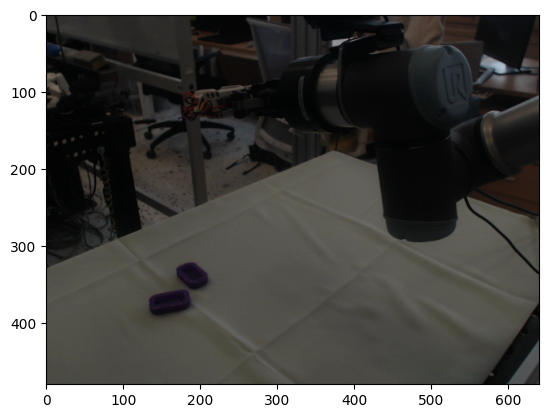

In [9]:
ret, frame = cap.read()
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
plt.imshow(frame_rgb)
cap.release()

### Delta Joint Angles

In [5]:
# camera init
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera")
    exit()

In [97]:
# rtde_r.getActualQ()
# Go to base pose
rtde_c.servoJ([-1.5807374159442347,
 -0.9485982100116175,
 1.6254310607910156,
 2.7482194900512695,
 -1.6201594511615198,
 0.04921172186732292], velocity, acceleration, dt, lookahead_time, gain)
gripper.move(5, 255, 10)
previous_image = None

In [72]:
previous_image = None

In [91]:
max_joint_rotation = 0.01

In [96]:
pose = rtde_r.getActualQ()
target_pose = np.empty(7)

image = get_image(cap, 256)
if previous_image is None:
    previous_image = copy.copy(image)
image_stacked = jnp.stack([previous_image, image], axis=0)
image_stacked = image_stacked[jnp.newaxis, ...]
observation = {"image_primary": image_stacked, 
               "timestep_pad_mask": jnp.array([[True, True]]),
               "timestep": jnp.array([[0, 1]]),
                "pad_mask_dict": {
                    "timestep": jnp.array([[True, True]]),  # Shape: (1, 2)
                    "image_primary": jnp.array([[True, True]])  # Shape: (1, 2)
                },
                "task_completed": jnp.zeros((1, 2, 4))}  # Shape: (1, 2, 4)

action = model.sample_actions(observation, task, rng=jax.random.PRNGKey(0),
                              unnormalization_statistics=model.dataset_statistics["action"],)[0][0]

print(action)
target_pose[:6] = np.array(pose) + np.clip(action[:6], a_min = -max_joint_rotation, a_max = max_joint_rotation)
target_pose[6] = round(action[6])

print('Current pose: ', pose)
print('Target pose: ', target_pose)

# if lib.isInJointLimits(target_pose[:-1]):
rtde_c.servoJ(target_pose[:-1], velocity, acceleration, dt, lookahead_time, gain)

gripper_pos = 150 if target_pose[6] else 10
if (gripper_pos < gripper._max_position - 25) and (gripper_pos > gripper._min_position):
    gripper.move(gripper_pos, 255, 10)
    sleep(0.01)

previous_image = copy.copy(image)

[-0.00075004  0.02442771 -0.00393985  0.01796819 -0.00170449 -0.0068865
  0.03151622]
Current pose:  [-1.8354485670672815, -1.0331457296954554, 1.9036622047424316, 3.6218366622924805, -1.0443990866290491, -0.2756288687335413]
Target pose:  [-1.83619869 -1.02314579  1.89972234  3.63183665 -1.0461036  -0.28251538
  0.        ]


In [26]:
if lib.isInJointLimits(target_pose[:-1]):
    rtde_c.servoJ(target_pose[:-1], velocity, acceleration, dt, lookahead_time, gain)

gripper_pos = 150 if target_pose[6] else 10
if (gripper_pos < gripper._max_position - 25) and (gripper_pos > gripper._min_position):
    gripper.move(gripper_pos, 255, 10)
    sleep(0.01)

previous_image = copy.copy(image)

00:17:59  - Wrist1 out of limit!


### Delta Joint Angles 2 Cameras

In [4]:
# Load model
model = OctoModel.load_pretrained("/home/erkhovaa/octo/model_checkpoints/octo_small_delta_angles/gray_cylinder_100/proprio_90k", 39999)
# model = OctoModel.load_pretrained("/home/erkhovaa/octo/model_checkpoints/octo_small_delta_angles/gray_cylinder_50/two_cam", 49999)

task_texts = ["Pick up the gray cylinder."]
task = model.create_tasks(texts=task_texts)

In [5]:
#  camera init
cap_main = cv2.VideoCapture(0)
if not cap_main.isOpened():
    print("Cannot open camera")
    exit()

cap_wrist = cv2.VideoCapture(2)
if not cap_wrist.isOpened():
    print("Cannot open camera")
    exit()

print(cap_main.isOpened())
print(cap_wrist.isOpened())

# cap_main.release()
# cap_wrist.release()

True
True


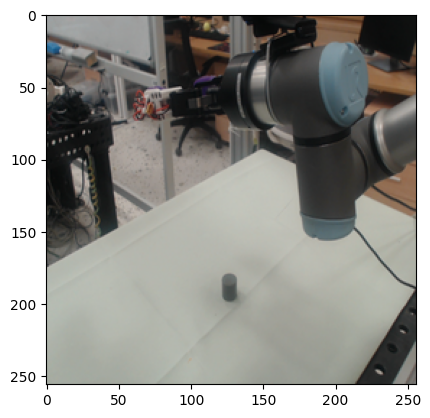

In [6]:
cap_main = cv2.VideoCapture(1)
plt.imshow(get_image(cap_main, 256))
cap_main.release()
# cap_wrist = cv2.VideoCapture(2)
# plt.imshow(get_image(cap_wrist, 256))
# cap_wrist.release()

In [6]:
# rtde_r.getActualQ()
# Go to base pose
rtde_c.servoJ([-1.5807374159442347,
 -0.9485982100116175,
 1.6254310607910156,
 2.7482194900512695,
 -1.6201594511615198,
 0.04921172186732292], velocity, acceleration, dt, lookahead_time, gain)
gripper.move(5, 255, 10)
previous_image_main = None
previous_image_wrist = None
previous_state = None

In [7]:
previous_image_main = None
previous_image_wrist = None
previous_state = None

In [8]:
max_joint_rotation = 0.15

In [49]:
cap_main = cv2.VideoCapture(1)
if not cap_main.isOpened():
    print("Cannot open camera")
    exit()

cap_wrist = cv2.VideoCapture(2)
if not cap_wrist.isOpened():
    print("Cannot open camera")
    exit()

pose = rtde_r.getActualQ()
target_pose = np.empty(7)

image_main = get_image(cap_main, 256)
image_wrist = get_image(cap_wrist, 128)
state = np.array(pose)

if previous_image_main is None:
    previous_image_main = copy.copy(image_main)
if previous_image_wrist is None:
    previous_image_wrist = copy.copy(image_wrist)
if previous_state is None:
    previous_state = copy.copy(state)

image_main_stacked = jnp.stack([previous_image_main, image_main], axis=0)
image_main_stacked = image_main_stacked[jnp.newaxis, ...]
image_wrist_stacked = jnp.stack([previous_image_wrist, image_wrist], axis=0)
image_wrist_stacked = image_wrist_stacked[jnp.newaxis, ...]
state_stacked = jnp.stack([previous_state, state], axis=0)
state_stacked = state_stacked[jnp.newaxis, ...]

observation = {"image_primary": image_main_stacked,
                "image_wrist": image_wrist_stacked,
                "proprio": state_stacked,
               "timestep_pad_mask": jnp.array([[True, True]]),
               "timestep": jnp.array([[0, 1]]),
                "pad_mask_dict": {
                    "timestep": jnp.array([[True, True]]),  # Shape: (1, 2)
                    "image_primary": jnp.array([[True, True]]),  # Shape: (1, 2)
                    "image_wrist": jnp.array([[True, True]]),  # Shape: (1, 2)
                    "proprio": jnp.array([[True, True]])  # Shape: (1, 2)
                },
                "task_completed": jnp.zeros((1, 2, 4))}  # Shape: (1, 2, 4)

action = model.sample_actions(observation, task, rng=jax.random.PRNGKey(0),
                              unnormalization_statistics=model.dataset_statistics["action"],)[0][0]

print('Gripper: ', action[6])
print(max(np.abs(action[:6])))
target_pose[:6] = np.array(pose) + np.clip(action[:6], a_min = -max_joint_rotation, a_max = max_joint_rotation)
target_pose[6] = round(action[6])

# print('Current pose: ', pose)
# print('Target pose: ', target_pose)

# if lib.isInJointLimits(target_pose[:-1]):
rtde_c.servoJ(target_pose[:-1], velocity, acceleration, dt, lookahead_time, gain)

gripper_pos = 150 if target_pose[6] else 10
if (gripper_pos < gripper._max_position - 25) and (gripper_pos > gripper._min_position):
    gripper.move(gripper_pos, 255, 10)
    sleep(0.01)

previous_image_main = copy.copy(image_main)
previous_image_wrist = copy.copy(image_wrist)
previous_state = copy.copy(state)

cap_main.release()
cap_wrist.release()

Gripper:  0.016403878
0.081330374


In [11]:
rtde_c.servoJ(target_pose[:-1], velocity, acceleration, dt, lookahead_time, gain)

gripper_pos = 150 if target_pose[6] else 10
if (gripper_pos < gripper._max_position - 25) and (gripper_pos > gripper._min_position):
    gripper.move(gripper_pos, 255, 10)
    sleep(0.01)

previous_image_main = copy.copy(image_main)
previous_image_wrist = copy.copy(image_wrist)

### Delta EEF 2 cameras

In [6]:
# Load model
model = OctoModel.load_pretrained("/home/erkhovaa/octo/model_checkpoints/octo_small_delta_eef/eef_50k", 49999)
# model = OctoModel.load_pretrained("/home/erkhovaa/octo/model_checkpoints/octo_small_delta_angles/gray_cylinder_50/two_cam", 49999)

task_texts = ["Pick up the gray cylinder."]
task = model.create_tasks(texts=task_texts)

In [7]:
#  camera init
cap_main = cv2.VideoCapture(0)
if not cap_main.isOpened():
    print("Cannot open camera")
    exit()

cap_wrist = cv2.VideoCapture(2)
if not cap_wrist.isOpened():
    print("Cannot open camera")
    exit()

print(cap_main.isOpened())
print(cap_wrist.isOpened())

cap_main.release()
cap_wrist.release()

True
True


In [8]:
previous_image_main = None
previous_image_wrist = None

In [32]:
# rtde_r.getActualQ()
# Go to base pose
gripper.move(5, 255, 10)
sleep(0.5)
rtde_c.servoJ([-1.5807374159442347,
 -0.9485982100116175,
 1.6254310607910156,
 2.7482194900512695,
 -1.6201594511615198,
 0.04921172186732292], velocity, acceleration, dt, lookahead_time, gain)
previous_image_main = None
previous_image_wrist = None
# previous_state = None

RTDEReceiveInterface boost system Exception: (asio.misc:2) End of file
RTDEControlInterface: Could not receive data from robot...
RTDEControlInterface Exception: End of file
RTDEControlInterface: Robot is disconnected, reconnecting...
RTDEControlInterface Exception: Timeout connecting to UR dashboard server.


Reconnecting...


In [11]:
def quaternion_multiply(quaternion1, quaternion0, reverse = False):
    x0, y0, z0, w0 = quaternion0
    x1, y1, z1, w1 = quaternion1

    return np.array([x1 * w0 + y1 * z0 - z1 * y0 + w1 * x0,
                     -x1 * z0 + y1 * w0 + z1 * x0 + w1 * y0,
                     x1 * y0 - y1 * x0 + z1 * w0 + w1 * z0,
                     -x1 * x0 - y1 * y0 - z1 * z0 + w1 * w0], dtype=np.float64)

In [31]:
cap_main = cv2.VideoCapture(0)
if not cap_main.isOpened():
    print("Cannot open camera")
    exit()

cap_wrist = cv2.VideoCapture(2)
if not cap_wrist.isOpened():
    print("Cannot open camera")
    exit()

ret, image = cap_main.read()
if not ret:
    print('Can not read')
    image = None

ret, image = cap_wrist.read()
if not ret:
    print('Can not read')
    image = None

pose = rtde_r.getActualTCPPose()
target_pose = np.empty(7)
image_main = get_image(cap_main, 256)
image_wrist = get_image(cap_wrist, 128)
# state = np.array(pose)

if previous_image_main is None:
    previous_image_main = copy.copy(image_main)
if previous_image_wrist is None:
    previous_image_wrist = copy.copy(image_wrist)
# if previous_state is None:
#     previous_state = copy.copy(state)

image_main_stacked = jnp.stack([previous_image_main, image_main], axis=0)
image_main_stacked = image_main_stacked[jnp.newaxis, ...]
image_wrist_stacked = jnp.stack([previous_image_wrist, image_wrist], axis=0)
image_wrist_stacked = image_wrist_stacked[jnp.newaxis, ...]
# state_stacked = jnp.stack([previous_state, state], axis=0)
# state_stacked = state_stacked[jnp.newaxis, ...]

observation = {"image_primary": image_main_stacked,
                "image_wrist": image_wrist_stacked,
                # "proprio": state_stacked,
               "timestep_pad_mask": jnp.array([[True, True]]),
               "timestep": jnp.array([[0, 1]]),
                "pad_mask_dict": {
                    "timestep": jnp.array([[True, True]]),  # Shape: (1, 2)
                    "image_primary": jnp.array([[True, True]]),  # Shape: (1, 2)
                    "image_wrist": jnp.array([[True, True]]),  # Shape: (1, 2)
                    # "proprio": jnp.array([[True, True]])  # Shape: (1, 2)
                },
                "task_completed": jnp.zeros((1, 2, 4))}  # Shape: (1, 2, 4)

action = model.sample_actions(observation, task, rng=jax.random.PRNGKey(0),
                              unnormalization_statistics=model.dataset_statistics["action"],)[0][0]

# print('Delta: ', action)
print('Max translation', max(np.abs(action[:3])))
print('Max rotation', max(np.abs(action[3:6])))

target_pose[:3] = np.array(pose[:3]) + action[:3]
# target_pose[3:6] = R.from_euler('zxy', R.from_rotvec(pose[3:]).as_euler('zxy') + action[3:6]).as_rotvec()
delta_q = R.from_euler('zxy', action[3:6]).as_quat()
q = R.from_rotvec(pose[3:]).as_quat()
target_pose[3:6] = R.from_quat(quaternion_multiply(q, delta_q)).as_rotvec()
target_pose[6] = round(action[6])
# target_pose[6] = 0

if rtde_c.getInverseKinematicsHasSolution(target_pose[:-1]):
    q = rtde_c.getInverseKinematics(target_pose[:-1])
    if lib.isInJointLimits(q):
        rtde_c.servoJ(q, velocity, acceleration, dt, lookahead_time, gain)

gripper_pos = 150 if target_pose[-1]==1 else 5
if (gripper_pos < gripper._max_position - 5) and (gripper_pos > gripper._min_position):
    gripper.move(gripper_pos, 255, 10)
    sleep(0.01)

previous_image_main = copy.copy(image_main)
previous_image_wrist = copy.copy(image_wrist)

cap_main.release()
cap_wrist.release()

Max translation 0.0059131146
Max rotation 0.0143260695


In [44]:
if rtde_c.getInverseKinematicsHasSolution(target_pose[:-1]):
    q = rtde_c.getInverseKinematics(target_pose[:-1])
    if lib.isInJointLimits(q):
        rtde_c.servoJ(q, velocity, acceleration, dt, lookahead_time, gain)

gripper_pos = 150 if target_pose[-1]==1 else 5
if (gripper_pos < gripper._max_position - 5) and (gripper_pos > gripper._min_position):
    gripper.move(gripper_pos, 255, 10)
    sleep(0.01)